In [2]:
using Plots, VeryDiff, VeryDiffPolyExperiments, SpecialFunctions, JLD2

Set parameter Username
Set parameter LicenseID to value 2751365
Academic license - for non-commercial use only - expires 2026-12-08
Set parameter Username
Set parameter LicenseID to value 2751365
Academic license - for non-commercial use only - expires 2026-12-08


In [3]:
gelu = x -> 0.5 * x * (1 + erf(x / sqrt(2)))

#23 (generic function with 1 method)

# Overflow Error

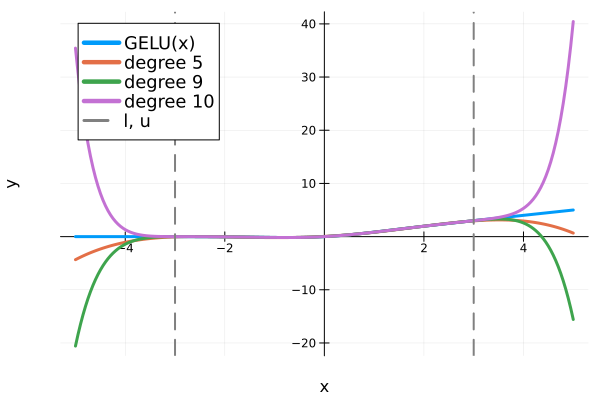

In [39]:
l, u = -3., 3.
degree = 5
degree2 = 9
degree3 = 10
δ = 2.

p, ϵ = VeryDiff.approx_gelu_poly(l, u, degree)
f = VeryDiff.make_eval_chebyshev(p, l, u)

p2, ϵ2 = VeryDiff.approx_gelu_poly(l, u, degree2)
f2 = VeryDiff.make_eval_chebyshev(p2, l, u)

p3, ϵ3 = VeryDiff.approx_gelu_poly(l, u, degree3)
f3 = VeryDiff.make_eval_chebyshev(p3, l, u)

xs = range(l - δ, u + δ, 200)
pl = plot(xs, gelu.(xs), xlabel="x", ylabel="y", legendfontsize=12, label="GELU(x)", framestyle=:origin, linewidth=3)
plot!(xs, f.(xs), label="degree $degree", linewidth=3)
plot!(xs, f2.(xs), label="degree $degree2", linewidth=3)
plot!(xs, f3.(xs), label="degree $degree3", linewidth=3)
vline!([l, u], label="l, u", linestyle=:dash, color=:gray, linewidth=2)

In [40]:
savefig(pl, "../fig/gelu/overflow_illustration.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/analysis/fig/gelu/overflow_illustration.pdf"

# GeLU Convergence

In [4]:
elu = x -> ifelse(x > 0, x, exp(x) - 1)
σ = x -> 1/(1 + exp(-x))
silu = x -> x * σ(x)

#32 (generic function with 1 method)

In [5]:
function error_sampling(f_p, f, l, u; n_samples=10000)
    xs = range(l, u, n_samples)
    ϵ  = maximum(abs.(f_p.(xs) .- f.(xs)))
end

error_sampling (generic function with 1 method)

In [6]:
# piecewise_params = load(joinpath(@__DIR__, "..", "..", "..", "PolynomialEquivalenceNN", "gelu_piecewise_poly_sampled_degree_15.jld2"))["params"]
gpp = VeryDiff.load_piecewise_poly(joinpath(@__DIR__, "..", "..", "..", "PolynomialEquivalenceNN", "gelu_piecewise_poly_sampled_degree_15.jld2"))
f_gpp = VeryDiff.make_eval_gelu_piecewise_poly(gpp)

#make_eval_gelu_piecewise_poly##0 (generic function with 1 method)

## For fixed interval

In [49]:
VeryDiff.ALMOST_ZERO_LEADING_COEFF_WARNING[] = false

l, u = -10., 10.
degrees = 5:5:120

errors_gelu = []
errors_gelu_cheby = []
errors_relu = []
errors_relu_cheby = []
errors_elu_cheby  = []
errors_σ_cheby  = []
errors_silu_cheby  = []
for d in degrees
    # ReLU
    p_cheby = VeryDiff.chebyshev_coefficients(x -> max(0., x), l, u, d)
    xs_err, ys_err = VeryDiff.relu_error_cheby(p_cheby, l, u)
    ϵ = maximum(abs.(ys_err))
    #f = VeryDiff.make_eval_chebyshev(p_cheby, l, u)
    #ϵ = error_sampling(f, x -> max(0., x), l, u) 
    push!(errors_relu_cheby, ϵ)

    p_relu, ϵ = VeryDiff.approx_relu_poly(l, u, d; max_iter=20) 
    #f = VeryDiff.make_eval_chebyshev(p_relu, l, u)
    #ϵ = error_sampling(f, x -> max(0., x), l, u) 
    push!(errors_relu, ϵ)

    # ELU
    p_cheby = VeryDiff.chebyshev_coefficients(elu, l, u, d)
    # only sampled error for ELU!
    f = VeryDiff.make_eval_chebyshev(p_cheby, l, u)
    ϵ = error_sampling(f, elu, l, u)    
    push!(errors_elu_cheby, ϵ)

    # sigmoid
    p_cheby = VeryDiff.chebyshev_coefficients(σ, l, u, d)
    # only sampled error for σ!
    f = VeryDiff.make_eval_chebyshev(p_cheby, l, u)
    ϵ = error_sampling(f, σ, l, u)    
    push!(errors_σ_cheby, ϵ)

    # SiLU
    p_cheby = VeryDiff.chebyshev_coefficients(silu, l, u, d)
    # only sampled error for SiLU!
    f = VeryDiff.make_eval_chebyshev(p_cheby, l, u)
    ϵ = error_sampling(f, silu, l, u)    
    push!(errors_silu_cheby, ϵ)
    
    # GeLU
    p_cheby = VeryDiff.chebyshev_coefficients(gelu, l, u, d)
    xs_err, ys_err = VeryDiff.piecewise_poly_error(gpp, p_cheby, l, u);
    ϵ = maximum(abs.(ys_err))
    #f = VeryDiff.make_eval_chebyshev(p_cheby, l, u)
    #ϵ = error_sampling(f, gelu, l, u) 
    push!(errors_gelu_cheby, ϵ)

    p_approx_pw, ϵ = VeryDiff.remez(f_gpp, (p, l, u) -> VeryDiff.piecewise_poly_error(gpp, p, l, u), VeryDiff.poly_norm, l, u, d, verbosity=0, max_iter=20)
    #f = VeryDiff.make_eval_chebyshev(p_approx_pw, l, u)
    #ϵ = error_sampling(f, gelu, l, u)  
    push!(errors_gelu, ϵ)
end

In [50]:
i = 10
println("degree: ", degrees[i])
println("GeLU")
println("\terror cheby: ", errors_gelu_cheby[i])
println("\terror Remez: ", errors_gelu[i])
println("ReLU")
println("\terror cheby: ", errors_relu_cheby[i])
println("\terror Remez: ", errors_relu[i])
println("ELU")
println("\terror cheby: ", errors_elu_cheby[i])
println("σ")
println("\terror cheby: ", errors_σ_cheby[i])
println("SiLU")
println("\terror cheby: ", errors_silu_cheby[i])

degree: 50
GeLU
	error cheby: 4.5436681696655115e-7
	error Remez: 2.2604929306169197e-7
ReLU
	error cheby: 0.05967380869188199
	error Remez: 0.02800992184993989
ELU
	error cheby: 0.00789661855130061
σ
	error cheby: 2.3205870214315638e-7
SiLU
	error cheby: 3.5120628461005055e-7


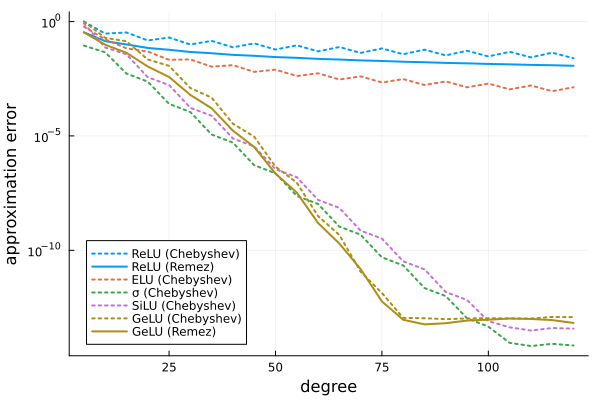

In [55]:
pl = plot(degrees, errors_relu_cheby, yscale=:log10, label="ReLU (Chebyshev)", xlabel="degree", ylabel="approximation error", legend=:bottomleft, color=1, linestyle=:dot, linewidth=2)
plot!(degrees, errors_relu, label="ReLU (Remez)", color=1, linewidth=2)
plot!(degrees, errors_elu_cheby, label="ELU (Chebyshev)", color=2, linestyle=:dot, linewidth=2)
plot!(degrees, errors_σ_cheby, label="σ (Chebyshev)", color=3, linestyle=:dot, linewidth=2)
plot!(degrees, errors_silu_cheby, label="SiLU (Chebyshev)", color=4, linestyle=:dot, linewidth=2)
plot!(degrees, errors_gelu_cheby, label="GeLU (Chebyshev)", color=5, linestyle=:dot, linewidth=2)
plot!(degrees, errors_gelu, label="GeLU (Remez)", color=5, linewidth=2)

In [56]:
savefig(pl, "../fig/gelu/convergence_approximation_error.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/analysis/fig/gelu/convergence_approximation_error.pdf"

## Intervals of Growing Size

In [7]:
VeryDiff.ALMOST_ZERO_LEADING_COEFF_WARNING[] = false

rs = range(1, 100, 20)
degrees = [5, 10, 20, 50]

result_dict = Dict()
for d in degrees
    println("fitting for degree ", d, " ... ")
    errors_gelu = []
    errors_gelu_cheby = []
    errors_relu = []
    errors_relu_cheby = []
    for r in rs 
        l, u = -r, r
        # ReLU
        p_cheby = VeryDiff.chebyshev_coefficients(x -> max(0., x), l, u, d)
        xs_err, ys_err = VeryDiff.relu_error_cheby(p_cheby, l, u)
        ϵ = maximum(abs.(ys_err))
        #f = VeryDiff.make_eval_chebyshev(p_cheby, l, u)
        #ϵ = error_sampling(f, x -> max(0., x), l, u) 
        push!(errors_relu_cheby, ϵ)

        p_relu, ϵ = VeryDiff.approx_relu_poly(l, u, d; max_iter=20) 
        #f = VeryDiff.make_eval_chebyshev(p_relu, l, u)
        #ϵ = error_sampling(f, x -> max(0., x), l, u) 
        push!(errors_relu, ϵ)
    
        # GeLU
        p_cheby = VeryDiff.chebyshev_coefficients(gelu, l, u, d)
        xs_err, ys_err = VeryDiff.piecewise_poly_error(gpp, p_cheby, l, u);
        ϵ = maximum(abs.(ys_err))
        #f = VeryDiff.make_eval_chebyshev(p_cheby, l, u)
        #ϵ = error_sampling(f, gelu, l, u) 
        push!(errors_gelu_cheby, ϵ)

        p_approx_pw, ϵ = VeryDiff.remez(f_gpp, (p, l, u) -> VeryDiff.piecewise_poly_error(gpp, p, l, u), VeryDiff.poly_norm, l, u, d, verbosity=0, max_iter=20)
        #f = VeryDiff.make_eval_chebyshev(p_approx_pw, l, u)
        #ϵ = error_sampling(f, gelu, l, u)  
        push!(errors_gelu, ϵ)
    end

    result_dict[d] = (errors_gelu, errors_gelu_cheby, errors_relu, errors_relu_cheby)
end

fitting for degree 5 ... 
fitting for degree 10 ... 
fitting for degree 20 ... 
fitting for degree 50 ... 


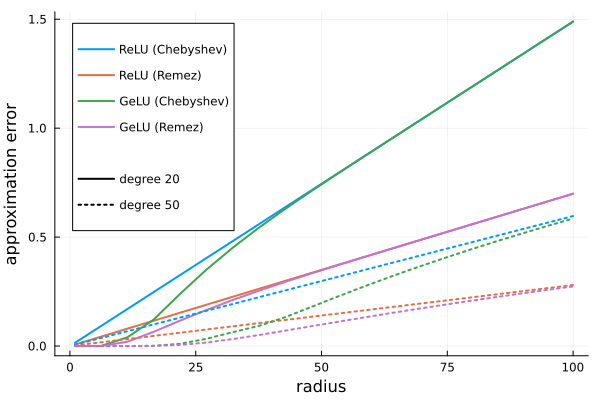

In [16]:
pl = plot(xlabel="radius", ylabel="approximation error")
linestyles = [:solid, :dot, :dash]
for (i, d) in enumerate(degrees[3:end])
    errors_gelu, errors_gelu_cheby, errors_relu, errors_relu_cheby = result_dict[d]
    plot!(rs, errors_relu_cheby, label=nothing, color=1, linestyle=linestyles[i], linewidth=2)
    plot!(rs, errors_relu, label=nothing, color=2, linestyle=linestyles[i], linewidth=2)
    plot!(rs, errors_gelu_cheby, label=nothing, color=3, linestyle=linestyles[i], linewidth=2)
    plot!(rs, errors_gelu, label=nothing, color=4, linestyle=linestyles[i], linewidth=2)
end

plot!([0], [0], label="ReLU (Chebyshev)", color=1, linewidth=2)
plot!([0], [0], label="ReLU (Remez)", color=2, linewidth=2)
plot!([0], [0], label="GeLU (Chebyshev)", color=3, linewidth=2)
plot!([0], [0], label="GeLU (Remez)", color=4, linewidth=2)

plot!([0], [0], label="\n", color = :white)

plot!([0], [0], label="degree 20", color = :black, linestyle=:solid, linewidth=2)
plot!([0], [0], label="degree 50", color = :black, linestyle=:dot, linewidth=2)

pl

In [17]:
savefig(pl, "../fig/gelu/convergence_approximation_error_radius.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/analysis/fig/gelu/convergence_approximation_error_radius.pdf"

# Bernstein Ellipse

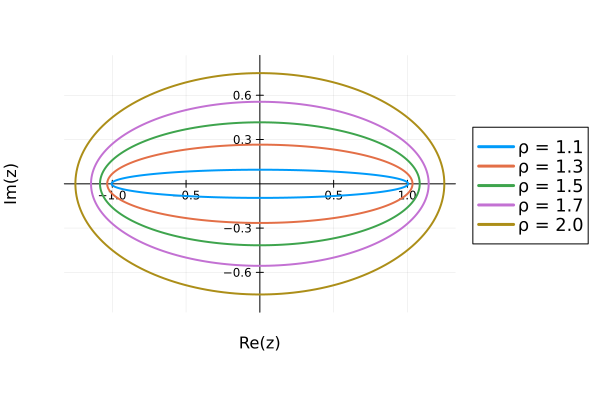

In [33]:
pl = plot(framestyle=:origin, xlabel="Re(z)", ylabel="Im(z)", legend=:outerright, legendfontsize=12, aspect_ratio=:equal)

ρs = [1.1, 1.3, 1.5, 1.7, 2]
for ρ in ρs
    θs = range(0, 2π, 200)
    us = ρ .* exp.(1im .* θs)
    zs = 0.5 .* (us .+ (1 ./ us))

    plot!(real.(zs), imag.(zs), label="ρ = $ρ", linewidth=2)
end

pl

In [34]:
savefig(pl, "../fig/gelu/bernstein_ellipse.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/analysis/fig/gelu/bernstein_ellipse.pdf"